# 1D CNN · 02 Data Audit

Checks the raw CSV for missing values, duplicates, encoding problems and outliers. **Needs:** the dataset. **Saves:** `cnn1d_audit_length_outliers.png`.

*Notebook 2 of 14 · Previous: 01 Setup · Next: 03 Dataset and Split*

## Setup (the same in every notebook)

Each notebook in this project is self-contained. The cells below define the group settings and only the helper functions this notebook uses. They are identical in every notebook and nothing is imported from another file, so the notebook also runs on its own, for example in Colab.

In [1]:
# ---- Imports, project folders and dataset location ----------------------------------------------
import sys, re, json, time, pathlib, textwrap
from collections import Counter
from dataclasses import dataclass

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from tensorflow import keras
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score, precision_score,
                             recall_score, roc_auc_score, roc_curve)

layers = keras.layers
IN_COLAB = "google.colab" in sys.modules

# CNN1D_ROOT is the folder that holds the numbered step folders (01_Setup, 02_Data_Audit, ...).
# If this notebook is opened on its own (for example in Colab), the current folder is used instead.
here = pathlib.Path.cwd().resolve()
CNN1D_ROOT = next((p for p in [here, *here.parents] if (p / "01_Setup").is_dir()), here)
RESULTS = CNN1D_ROOT / "results"              # figures, metrics, predictions and trained models are saved here
RESULTS.mkdir(exist_ok=True)

# The dataset is the only input file.
DATA_NAME = "deceptive-opinion.csv"
search_in = [CNN1D_ROOT, CNN1D_ROOT / "dataset", CNN1D_ROOT.parent / "dataset", here, here / "dataset",
             pathlib.Path("/content")]
DATA_PATH = next((d / DATA_NAME for d in search_in if (d / DATA_NAME).exists()), None)

if DATA_PATH is None and IN_COLAB:
    from google.colab import files
    print(f"Please choose {DATA_NAME} from your computer...")
    uploaded = files.upload()                       # saved in the current folder
    DATA_PATH = here / next(iter(uploaded))
if DATA_PATH is None:
    raise FileNotFoundError(f"Cannot find {DATA_NAME}. Put it in a 'dataset' folder next to the step folders "
                            "(or next to this notebook) and run this cell again.")

print("Dataset:", DATA_PATH)
print("Results folder:", RESULTS)

Dataset: /Volumes/Dilmith Ext/Deep-Learning---Assignment/dataset/deceptive-opinion.csv
Results folder: /Volumes/Dilmith Ext/Deep-Learning---Assignment/cnn1d/results


In [2]:
# ---- Group settings: identical for Simple RNN, LSTM, GRU and 1D CNN ------------------------------
SEED = 42

# Labels: this dataset has no star rating, so the `polarity` column is the label.
LABEL_COLUMN = "polarity"
LABEL_MAP = {"negative": 0, "positive": 1}

# Text -> integer sequences
VOCAB_SIZE = 5000          # total ids, including <PAD>=0 and <OOV>=1
MAX_LEN = 300              # tokens per review after cleaning
PAD_TOKEN, OOV_TOKEN = "<PAD>", "<OOV>"
PADDING = "pre"            # zeros in front, so a recurrent layer ends on real words
TRUNCATING = "post"        # long reviews keep their first MAX_LEN tokens

# Training
EMBED_DIM = 64
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
MAX_EPOCHS = 30
PATIENCE = 5               # EarlyStopping patience, monitoring validation loss
MONITOR = "val_loss"
THRESHOLD = 0.5            # probability cut-off used for every model's test metrics

# Fixed 80/10/10 split (stratified on the label, seed 42, made after removing duplicates).
# Numbers are 0-based row positions in deceptive-opinion.csv. Every row not listed here is a TRAINING row.
# All four models must use exactly these two lists.
VAL_IDS = {
    3, 4, 6, 7, 14, 24, 25, 27, 33, 38, 46, 50, 60, 66, 72, 74, 77, 85, 89, 92, 106, 110, 112, 136,
    144, 172, 211, 215, 224, 230, 238, 242, 248, 252, 288, 302, 311, 319, 336, 345, 368, 376, 385,
    393, 402, 404, 434, 440, 442, 465, 473, 510, 512, 515, 517, 524, 533, 536, 542, 549, 553, 558,
    579, 581, 594, 603, 624, 630, 638, 644, 645, 661, 663, 665, 699, 713, 729, 754, 760, 788, 801,
    813, 820, 821, 827, 832, 840, 864, 873, 893, 897, 900, 904, 907, 908, 923, 930, 936, 962, 963,
    989, 991, 1002, 1008, 1017, 1043, 1045, 1054, 1073, 1098, 1112, 1119, 1134, 1143, 1170, 1189,
    1191, 1201, 1239, 1258, 1262, 1263, 1264, 1270, 1280, 1295, 1308, 1309, 1314, 1328, 1344, 1350,
    1359, 1360, 1364, 1367, 1368, 1369, 1370, 1377, 1378, 1381, 1418, 1423, 1450, 1467, 1479, 1480,
    1490, 1505, 1506, 1522, 1547, 1551, 1552, 1573, 1578, 1588, 1593, 1594
}
TEST_IDS = {
    0, 2, 5, 9, 39, 45, 47, 55, 108, 117, 120, 125, 138, 139, 145, 171, 191, 193, 213, 222, 227,
    228, 232, 256, 258, 260, 272, 273, 276, 281, 299, 314, 321, 325, 349, 362, 364, 391, 409, 424,
    436, 445, 467, 469, 484, 502, 503, 505, 507, 523, 525, 531, 545, 547, 572, 573, 605, 606, 612,
    622, 623, 633, 669, 671, 681, 687, 691, 698, 718, 725, 731, 741, 752, 753, 765, 770, 771, 779,
    784, 785, 804, 814, 834, 835, 847, 852, 859, 866, 882, 887, 889, 901, 932, 940, 958, 961, 968,
    972, 993, 1003, 1007, 1019, 1020, 1033, 1044, 1046, 1055, 1072, 1076, 1079, 1091, 1117, 1141,
    1147, 1149, 1151, 1176, 1182, 1183, 1193, 1195, 1196, 1205, 1210, 1217, 1222, 1231, 1259, 1265,
    1275, 1278, 1279, 1288, 1293, 1296, 1302, 1306, 1312, 1324, 1357, 1365, 1366, 1396, 1404, 1416,
    1446, 1451, 1465, 1478, 1485, 1487, 1492, 1503, 1504, 1516, 1524, 1540, 1562, 1582, 1597
}
keras.utils.set_random_seed(SEED)          # seeds Python, NumPy and TensorFlow
print("TensorFlow", tf.__version__, "| Keras", keras.__version__, "| seed", SEED)
print("Devices:", [d.device_type for d in tf.config.list_physical_devices()])

TensorFlow 2.21.0 | Keras 3.15.1 | seed 42
Devices: ['CPU']


In [3]:
# ---- Data pipeline: load -> label -> de-duplicate -> split -> clean -> vocabulary -> pad ----------
# Leakage rule: the vocabulary and the class weights are built from TRAINING rows only.
# Validation and test rows are only ever encoded with the training vocabulary.

def load_labelled_data() -> pd.DataFrame:
    """Read the CSV, map polarity -> 0/1 and drop exact duplicate reviews.

    Duplicates must go before splitting, otherwise a copy of a training review could land in the
    test set and the test set would no longer be unseen.
    """
    df = pd.read_csv(DATA_PATH)
    df["row_id"] = np.arange(len(df))                   # 0-based row number in the CSV
    df["text"] = df["text"].astype(str).str.strip()
    df["label"] = df[LABEL_COLUMN].map(LABEL_MAP)
    assert df["label"].notna().all(), "unexpected label value"
    df["label"] = df["label"].astype(int)
    df = df.drop_duplicates(subset="text", keep="first").reset_index(drop=True)
    return df[["row_id", "text", "label", "hotel", "deceptive", "source"]]


def assign_split(df: pd.DataFrame) -> np.ndarray:
    """'train' / 'val' / 'test' for every row, from the fixed id lists above."""
    if not (VAL_IDS | TEST_IDS) <= set(df["row_id"]):
        raise ValueError("The fixed validation/test ids do not match this dataset. Was the CSV changed?")
    return np.where(df["row_id"].isin(TEST_IDS), "test",
                    np.where(df["row_id"].isin(VAL_IDS), "val", "train"))


# Text cleaning: identical for all models; a pure per-review function, nothing is fitted.
_HTML = re.compile(r"<[^>]+>")
_URL = re.compile(r"(https?://\S+|www\.\S+)")
_CONTRACTIONS = [                       # keep negation: "didn't" -> "did not", not "didn t"
    (r"\bwon't\b", "will not"), (r"\bcan't\b", "can not"), (r"\bcannot\b", "can not"),
    (r"n't\b", " not"), (r"'re\b", " are"), (r"'ve\b", " have"), (r"'ll\b", " will"),
    (r"'d\b", " would"), (r"'m\b", " am"), (r"'s\b", ""),
]
_NON_LETTER = re.compile(r"[^a-z\s]")
_SPACES = re.compile(r"\s+")


def clean_text(text: str) -> str:
    """lowercase -> strip HTML -> strip URLs -> expand contractions -> keep letters only.

    Stop-words are deliberately NOT removed: words such as "not", "no" and "never" flip the sentiment.
    """
    text = text.lower().replace("’", "'")
    text = _HTML.sub(" ", text)
    text = _URL.sub(" ", text)
    for pattern, replacement in _CONTRACTIONS:
        text = re.sub(pattern, replacement, text)
    text = _NON_LETTER.sub(" ", text)           # digits, punctuation, symbols
    return _SPACES.sub(" ", text).strip()


def build_vocab(train_token_lists, vocab_size: int = VOCAB_SIZE) -> dict:
    """Most frequent TRAINING words -> ids. 0 = <PAD>, 1 = <OOV>, real words start at 2."""
    counts = Counter(tok for tokens in train_token_lists for tok in tokens)
    words = [w for w, _ in counts.most_common(vocab_size - 2)]
    vocab = {PAD_TOKEN: 0, OOV_TOKEN: 1}
    vocab.update({w: i + 2 for i, w in enumerate(words)})
    return vocab


def encode(tokens, vocab: dict) -> list:
    oov = vocab[OOV_TOKEN]
    return [vocab.get(t, oov) for t in tokens]


def decode(ids, vocab: dict, skip_pad: bool = True) -> list:
    """Inverse of `encode`: ids -> words. Unknown words come back as <OOV> (the original is lost)."""
    inverse = {i: w for w, i in vocab.items()}
    return [inverse[int(i)] for i in ids if not (skip_pad and int(i) == 0)]


def pad(sequences, max_len: int = MAX_LEN) -> np.ndarray:
    out = np.zeros((len(sequences), max_len), dtype="int32")
    for i, seq in enumerate(sequences):
        seq = seq[:max_len] if TRUNCATING == "post" else seq[-max_len:]
        if PADDING == "pre":
            out[i, max_len - len(seq):] = seq
        else:
            out[i, :len(seq)] = seq
    return out


def compute_class_weights(y_train) -> dict:
    """weight_c = n_samples / (n_classes * n_samples_in_class_c)   (same as sklearn 'balanced')."""
    classes, counts = np.unique(y_train, return_counts=True)
    return {int(c): float(len(y_train) / (len(classes) * n)) for c, n in zip(classes, counts)}


@dataclass
class Data:
    X_train: np.ndarray
    y_train: np.ndarray
    X_val: np.ndarray
    y_val: np.ndarray
    X_test: np.ndarray
    y_test: np.ndarray
    vocab: dict
    class_weight: dict
    train_df: pd.DataFrame     # raw + cleaned text, kept for EDA / error analysis
    val_df: pd.DataFrame
    test_df: pd.DataFrame


def prepare_data() -> Data:
    """Everything a model needs, in one call."""
    df = load_labelled_data()
    df["split"] = assign_split(df)
    df["clean"] = df["text"].map(clean_text)
    df["tokens"] = df["clean"].str.split()

    parts = {name: g.reset_index(drop=True) for name, g in df.groupby("split")}
    vocab = build_vocab(parts["train"]["tokens"].tolist())          # <- TRAIN ONLY

    def to_xy(part: pd.DataFrame):
        seqs = [encode(tokens, vocab) for tokens in part["tokens"]]
        return pad(seqs), part["label"].to_numpy(dtype="int32")

    X_train, y_train = to_xy(parts["train"])
    X_val, y_val = to_xy(parts["val"])
    X_test, y_test = to_xy(parts["test"])
    return Data(X_train, y_train, X_val, y_val, X_test, y_test, vocab,
                compute_class_weights(y_train), parts["train"], parts["val"], parts["test"])

In [4]:
# ---- Plot helpers: same figure style for all models -----------------------------------------------
# White background, thin lines, light grid, no top/right frame, text in neutral ink, legend for 2+ series.
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e5e4e0"
BLUE_RAMP = LinearSegmentedColormap.from_list("blue_seq", ["#cde2fb", "#3987e5", "#0d366b"])

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.edgecolor": GRID, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "legend.frameon": False, "lines.linewidth": 2,
})


def save_and_show(fig, path=None, show=True):
    fig.tight_layout()
    if path:
        fig.savefig(path)
    if show:
        plt.show()
    plt.close(fig)


def plot_curve(history: dict, metric: str, model_name: str, best_epoch=None, path=None, show=True):
    """Training vs validation curve for 'accuracy' or 'loss'."""
    train, val = history[metric], history["val_" + metric]
    epochs = np.arange(1, len(train) + 1)
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.plot(epochs, train, color=BLUE, label="Training")
    ax.plot(epochs, val, color=ORANGE, label="Validation")
    for series, color, name in ((train, BLUE, "Training"), (val, ORANGE, "Validation")):
        ax.plot(epochs[-1], series[-1], "o", color=color, markersize=6,
                markeredgecolor="white", markeredgewidth=1.5)
        ax.annotate(name, (epochs[-1], series[-1]), xytext=(8, 0), textcoords="offset points",
                    va="center", color=INK2, fontsize=10)
    if best_epoch:
        ax.axvline(best_epoch, color=INK2, linestyle=":", linewidth=1.2)
        ax.text(best_epoch, ax.get_ylim()[1], f" best epoch {best_epoch}", color=INK2,
                fontsize=9, va="top", ha="left")
    ax.set_xlim(0.7, epochs[-1] + 0.15 * max(epochs[-1], 6))
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f"{model_name}: training vs validation {metric}", loc="left")
    ax.legend(loc="best")
    save_and_show(fig, path, show)


def plot_confusion_matrix(cm: np.ndarray, model_name: str, path=None, show=True):
    """2x2 confusion matrix (rows = true class, columns = predicted class)."""
    labels = ["Negative", "Positive"]
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    ax.imshow(cm, cmap=BLUE_RAMP, vmin=0, vmax=cm.max())
    ax.grid(False)
    for i in range(2):
        for j in range(2):
            dark = cm[i, j] > cm.max() * 0.55
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=18,
                    fontweight="bold", color="white" if dark else INK)
    ax.set_xticks([0, 1], labels)
    ax.set_yticks([0, 1], labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{model_name}: confusion matrix (test)", loc="left")
    for s in ax.spines.values():
        s.set_visible(False)
    save_and_show(fig, path, show)


def plot_roc(y_true, y_prob, auc: float, model_name: str, threshold: float = 0.5, path=None, show=True):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5.2, 4.8))
    ax.plot([0, 1], [0, 1], color=INK2, linestyle="--", linewidth=1.2)
    ax.text(0.55, 0.47, "chance (AUC = 0.50)", color=INK2, fontsize=9, rotation=33)
    ax.plot(fpr, tpr, color=BLUE)
    k = np.argmin(np.abs(thr - threshold))          # operating point at the 0.5 cut-off
    ax.plot(fpr[k], tpr[k], "o", color=ORANGE, markersize=8, markeredgecolor="white", markeredgewidth=1.5)
    ax.annotate(f"threshold {threshold}", (fpr[k], tpr[k]), xytext=(10, -14),
                textcoords="offset points", color=INK2, fontsize=9)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"{model_name}: ROC curve (test), AUC = {auc:.3f}", loc="left")
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.01, 1.01)
    ax.set_aspect("equal")
    save_and_show(fig, path, show)


def plot_probability_hist(y_true, y_prob, model_name: str, threshold: float = 0.5, path=None, show=True):
    """How confident is the model? Predicted P(positive), split by the true class (stacked bars)."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob).ravel()
    bins = np.linspace(0, 1, 21)
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.hist([y_prob[y_true == 1], y_prob[y_true == 0]], bins=bins, stacked=True,
            color=[BLUE, ORANGE], label=["True positive reviews", "True negative reviews"],
            edgecolor="white", linewidth=1.5)
    ax.axvline(threshold, color=INK2, linestyle=":", linewidth=1.2)
    ax.set_xlabel("Predicted probability of positive")
    ax.set_ylabel("Number of test reviews")
    ax.set_title(f"{model_name}: confidence on the test set", loc="left")
    ax.legend(loc="upper center")
    save_and_show(fig, path, show)

## Data audit (cleaning checks on the raw file)

Before modelling we check the raw CSV for **missing values, duplicates, encoding problems and outliers**.
These are hygiene checks. They learn nothing from the data, and the only rows removed are exact duplicate reviews, so they are run on the whole file before the split and every model gets the same result.

In [5]:
raw = pd.read_csv(DATA_PATH)                       # the file exactly as given
text = raw["text"].astype(str).str.strip()
cleaned = text.map(clean_text)

print(f"Rows: {len(raw):,} | columns: {list(raw.columns)}\n")
print("MISSING VALUES / BLANK TEXT")
print(pd.DataFrame({"dtype": raw.dtypes.astype(str), "missing": raw.isna().sum(),
                    "blank": [(raw[c].astype(str).str.strip() == "").sum() for c in raw.columns]}).to_string())
print("\nLabel values found:", raw["polarity"].value_counts().to_dict(), "-> encoded with", LABEL_MAP)

print("\nDUPLICATES")
print("  exact duplicate rows (all columns):", raw.duplicated().sum())
print("  duplicate review texts:", text.duplicated().sum())
print("  duplicates after cleaning (ignoring case / punctuation / digits):", cleaned.duplicated().sum())
print("  duplicate texts with conflicting labels:", raw.assign(t=text).groupby("t")["polarity"].nunique().gt(1).sum())
print("  extra reviews that only share their first 200 characters with another review:",
      cleaned.str[:200].duplicated().sum() - cleaned.duplicated().sum())

print("\nENCODING")
print("  reviews with non-ASCII characters:", sum(any(ord(ch) > 127 for ch in s) for s in text))
print("  replacement characters (U+FFFD):", text.str.contains("\ufffd").sum(),
      "| mojibake patterns:", text.str.contains("Ã|â€|Â").sum())
print("  reviews containing HTML tags:", text.str.contains(r"<[^>]+>").sum(),
      "| URLs:", text.str.contains(r"https?://|www\.").sum(), "| digits:", text.str.contains(r"\d").sum())

Rows: 1,600 | columns: ['deceptive', 'hotel', 'polarity', 'source', 'text']

MISSING VALUES / BLANK TEXT
          dtype  missing  blank
deceptive   str        0      0
hotel       str        0      0
polarity    str        0      0
source      str        0      0
text        str        0      0

Label values found: {'positive': 800, 'negative': 800} -> encoded with {'negative': 0, 'positive': 1}

DUPLICATES
  exact duplicate rows (all columns): 4
  duplicate review texts: 4
  duplicates after cleaning (ignoring case / punctuation / digits): 4
  duplicate texts with conflicting labels: 0
  extra reviews that only share their first 200 characters with another review: 1

ENCODING
  reviews with non-ASCII characters: 0
  replacement characters (U+FFFD): 0 | mojibake patterns: 0
  reviews containing HTML tags: 0 | URLs: 2 | digits: 820


OUTLIERS: review length in tokens (IQR rule)
  min 25 | Q1 88 | median 128 | Q3 182 | max 795
  fences: lower -53, upper 324 -> 0 reviews below, 75 above (4.7%)
  reviews that are empty after cleaning: 0


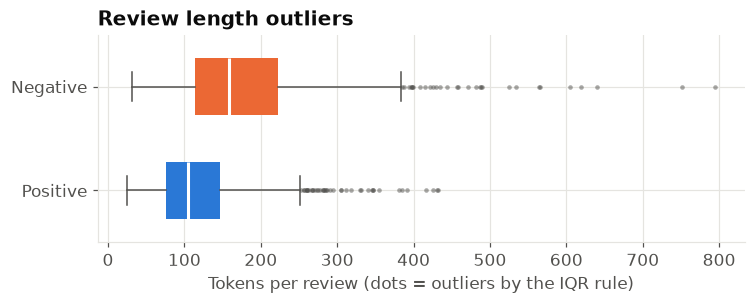

In [6]:
tokens = cleaned.str.split().map(len)
q1, q3 = tokens.quantile([0.25, 0.75])
lower, upper = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
print("OUTLIERS: review length in tokens (IQR rule)")
print(f"  min {tokens.min()} | Q1 {q1:.0f} | median {tokens.median():.0f} | Q3 {q3:.0f} | max {tokens.max()}")
print(f"  fences: lower {lower:.0f}, upper {upper:.0f} -> {int((tokens < lower).sum())} reviews below, "
      f"{int((tokens > upper).sum())} above ({100 * (tokens > upper).mean():.1f}%)")
print(f"  reviews that are empty after cleaning: {int((tokens == 0).sum())}")

fig, ax = plt.subplots(figsize=(7, 2.9))
groups = [tokens[raw["polarity"] == k] for k in ("positive", "negative")]
box_style = dict(widths=0.55, patch_artist=True,
                 flierprops=dict(marker="o", markersize=3, markerfacecolor=INK2, markeredgecolor="none", alpha=0.5),
                 medianprops=dict(color="white", linewidth=2), whiskerprops=dict(color=INK2), capprops=dict(color=INK2))
try:
    bp = ax.boxplot(groups, orientation="horizontal", **box_style)
except TypeError:                                   # older matplotlib (before 3.10)
    bp = ax.boxplot(groups, vert=False, **box_style)
for box, colour in zip(bp["boxes"], (BLUE, ORANGE)):
    box.set(facecolor=colour, edgecolor="none")
ax.set_yticks([1, 2], ["Positive", "Negative"])
ax.set_xlabel("Tokens per review (dots = outliers by the IQR rule)")
ax.set_title("Review length outliers", loc="left")
save_and_show(fig, RESULTS / "cnn1d_audit_length_outliers.png")

**What we do about each issue**

| Check | Action |
|---|---|
| Missing values / blank text | None needed if the counts above are zero. Otherwise such rows would be dropped for all models |
| Duplicates | Exact duplicate reviews are dropped (first copy kept) in `load_labelled_data()`, **before** the split, so a copy of a training review cannot appear in the test set |
| Encoding | The file is read as UTF-8. Curly apostrophes are normalised and all remaining non-letters are removed by the cleaning step |
| Outliers | **Kept.** Long reviews are real opinions and are cut to `MAX_LEN` in notebook 05. Short reviews are still valid. Removing outliers would change what the test set contains and make the four models incomparable |

---
*Notebook 2 of 14 · Previous: 01 Setup · Next: 03 Dataset and Split*